In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt

import seaborn as sns

from matplotlib_venn import venn3

import statsmodels.api as sm

from math import sqrt


import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

In [2]:
# dado com os modelos 
#df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_27_03_2026_with_MEM_EVI.parquet")
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_05_2026_with_MEM_all_mods_ens.parquet')

dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')


#df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_13-04-2026_mlp_xgb_withConsec.parquet')
df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_predicoes_producao_mlp.parquet')

df_ens_and = df_ens_and[['co_ibge', 'year_week','prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50']]
#df_ens_and = df_ens_and.rename(columns={'prob_ensemble_xgb':'prob_ensemble_xgb2', 'signal_ensemble_xgb50': 'signal_ensemble_xgb502', 
#                           'prob_ensemble_mlp':'prob_ensemble_mlp2', 'signal_ensemble_mlp50':'signal_ensemble_mlp502'})

df_merged = df.merge(df_ens_and, on=['co_ibge', 'year_week'], how='inner')

df = df_merged.copy()

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]

In [3]:
# Classify MEM surges accordingly to intensity
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [4]:
# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan


In [5]:
import warnings
warnings.filterwarnings('ignore')

lst = []

for code in df.co_ibge.unique():

    #print(code)

    set_muni = df[df.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    base = thresholds['baseline'].astype(int)
    epi = thresholds['epidemic_threshold'].astype(int)
    low = thresholds['low_level'].astype(int)
    med = thresholds['medium_level'].astype(int)
    high = thresholds['high_level'].astype(int)
    very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


In [6]:
result = pd.concat(lst)
result['mem_low'] = ((result['intensity'] == 'low') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_medium'] = ((result['intensity'] == 'medium') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_high'] = ((result['intensity'] == 'high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_very_high'] = ((result['intensity'] == 'very high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)

In [7]:
result['mem_low_consec'] = ((result['intensity'] == 'low') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_medium_consec'] = ((result['intensity'] == 'medium') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_high_consec'] = ((result['intensity'] == 'high') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_very_high_consec'] = ((result['intensity'] == 'very high') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)

In [8]:
result = result[['co_ibge', 'year_week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'signal_ensemble_xgb50', 
       'signal_ensemble_mlp50', 'hard_voting_ivas', 
       'risk_probs', 'sinal_ens_ivas_new', 'block', 'intensity', 'mem_low',
       'mem_medium', 'mem_high', 'mem_very_high', 'mem_low_consec',
        'mem_medium_consec','mem_high_consec', 'mem_very_high_consec']]

In [9]:
# select period

data = result[result.year_week >= '2025-01']


models = ['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',
          'signal_ensemble_xgb50',
          'signal_ensemble_mlp50',
          'sinal_ens_ivas_new',
          'hard_voting_ivas'
]

warn_col = 'warning_final_mem_surge_01'

warn_col_with_consec = 'mem_surge_01_correct_with_consec'

In [10]:
# Get peformance
lst1 = []
lst2 = []

for sel_model in models:

    print(sel_model)

    df_warning_count = des_fun.antici_count(data, sel_model, warn_col,warn_col_with_consec, 'co_ibge')
    
    performance_summary = des_fun.summarize_performance(df_warning_count)

    performance_summary['model'] = sel_model
    df_warning_count['model'] = sel_model

    lst1.append(performance_summary)
    lst2.append(df_warning_count)
        
summary =  pd.concat(lst1)

sinal_ears_atend
sinal_evi_ivas
EWS_ISF
EWS_LOF
EWS_OCSVM
EWS_COPOD
EWS_Rt
signal_ensemble_xgb50
signal_ensemble_mlp50
sinal_ens_ivas_new
hard_voting_ivas


In [11]:
summary[summary.Metric == '3 weeks earlier']

,Metric,Value,model
13,3 weeks earlier,30.4,sinal_ears_atend
13,3 weeks earlier,28.0,sinal_evi_ivas
13,3 weeks earlier,11.0,EWS_ISF
13,3 weeks earlier,13.9,EWS_LOF
13,3 weeks earlier,11.6,EWS_OCSVM
13,3 weeks earlier,11.5,EWS_COPOD
13,3 weeks earlier,14.1,EWS_Rt
13,3 weeks earlier,30.9,signal_ensemble_xgb50
13,3 weeks earlier,32.8,signal_ensemble_mlp50
13,3 weeks earlier,32.8,sinal_ens_ivas_new


In [12]:

# --- Wilson confidence interval ---
def proportion_confint_wilson(successes, n, alpha=0.05):
    """Wilson score confidence interval for a proportion"""
    if n == 0:
        return (np.nan, np.nan)
    z = 1.96  # 95% CI
    p = successes / n
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    adj = z * sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    lower = (centre - adj) / denom
    upper = (centre + adj) / denom
    return lower * 100, upper * 100  # return in percentage


# --- Function to calculate CIs from summarize_performance output ---
def performance_with_CI(summary_df):
    """
    Takes summarize_performance() output and adds 95% CI for Sensitivity, Specificity,
    PPV, POD, FPR, and Precision.
    """
    # Extract numeric counts from your summary table
    total_warnings = int(summary_df.loc[summary_df["Metric"] == "Total Warnings", "Value"].values[0])
    #TP_FN = int(summary_df.loc[summary_df["Metric"] == "TP + FN", "Value"].values[0])
    #TN_FP = int(summary_df.loc[summary_df["Metric"] == "TN + FP", "Value"].values[0])
    #TP_FP = int(summary_df.loc[summary_df["Metric"] == "TN + FN", "Value"].values[0])
    
    TP = int(summary_df.loc[summary_df["Metric"] == "TP", "Value"].values[0])
    FN = int(summary_df.loc[summary_df["Metric"] == "FN", "Value"].values[0])
    TN = int(summary_df.loc[summary_df["Metric"] == "TN", "Value"].values[0])
    FP = int(summary_df.loc[summary_df["Metric"] == "FP", "Value"].values[0])
    TP_ = int(summary_df.loc[summary_df["Metric"] == "TP_", "Value"].values[0])

    # Recover metric estimates (as percentages)
    sens = float(summary_df.loc[summary_df["Metric"] == "Sensitivity ", "Value"].values[0].strip("%"))
    spec = float(summary_df.loc[summary_df["Metric"] == "Specificity", "Value"].values[0].strip("%"))
    ppv  = float(summary_df.loc[summary_df["Metric"] == "PPV", "Value"].values[0].strip("%"))
    npv  = float(summary_df.loc[summary_df["Metric"] == "NPV", "Value"].values[0].strip("%"))

    
    # --- Compute 95% CIs ---
    metrics = {
        "Sensitivity": (TP, TP + FN),
        "Specificity": (TN, TN + FP),
        "PPV": (TP_, TP_ + FP),
        "NPV": (TN, TN + FN)
    }

    results = []
    for metric, (x, n) in metrics.items():
        estimate = (x / n) * 100 if n > 0 else np.nan
        ci_low, ci_high = proportion_confint_wilson(x, n)
        results.append({
            "Metric": metric,
            "Estimate": round(estimate, 2),
            "CI_Low": round(ci_low, 2),
            "CI_High": round(ci_high, 2),
            "n": n
        })

    return pd.DataFrame(results)



In [13]:
summary.model = summary.model.replace({'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI', 'signal_ensemble_xgb50': 'XGBOOST',
                         'signal_ensemble_mlp50':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'MV'})

In [14]:
lst = []

for mod in summary.model.unique():
    dta = performance_with_CI(summary[summary.model == mod])
    dta = dta.assign(model = mod)

    lst.append(dta)

In [15]:
res = pd.concat(lst)

In [16]:
res = res.assign(Estimate = res.Estimate.astype(float),
                CI_Low = res.CI_Low.astype(float),
                CI_High = res.CI_High.astype(float))

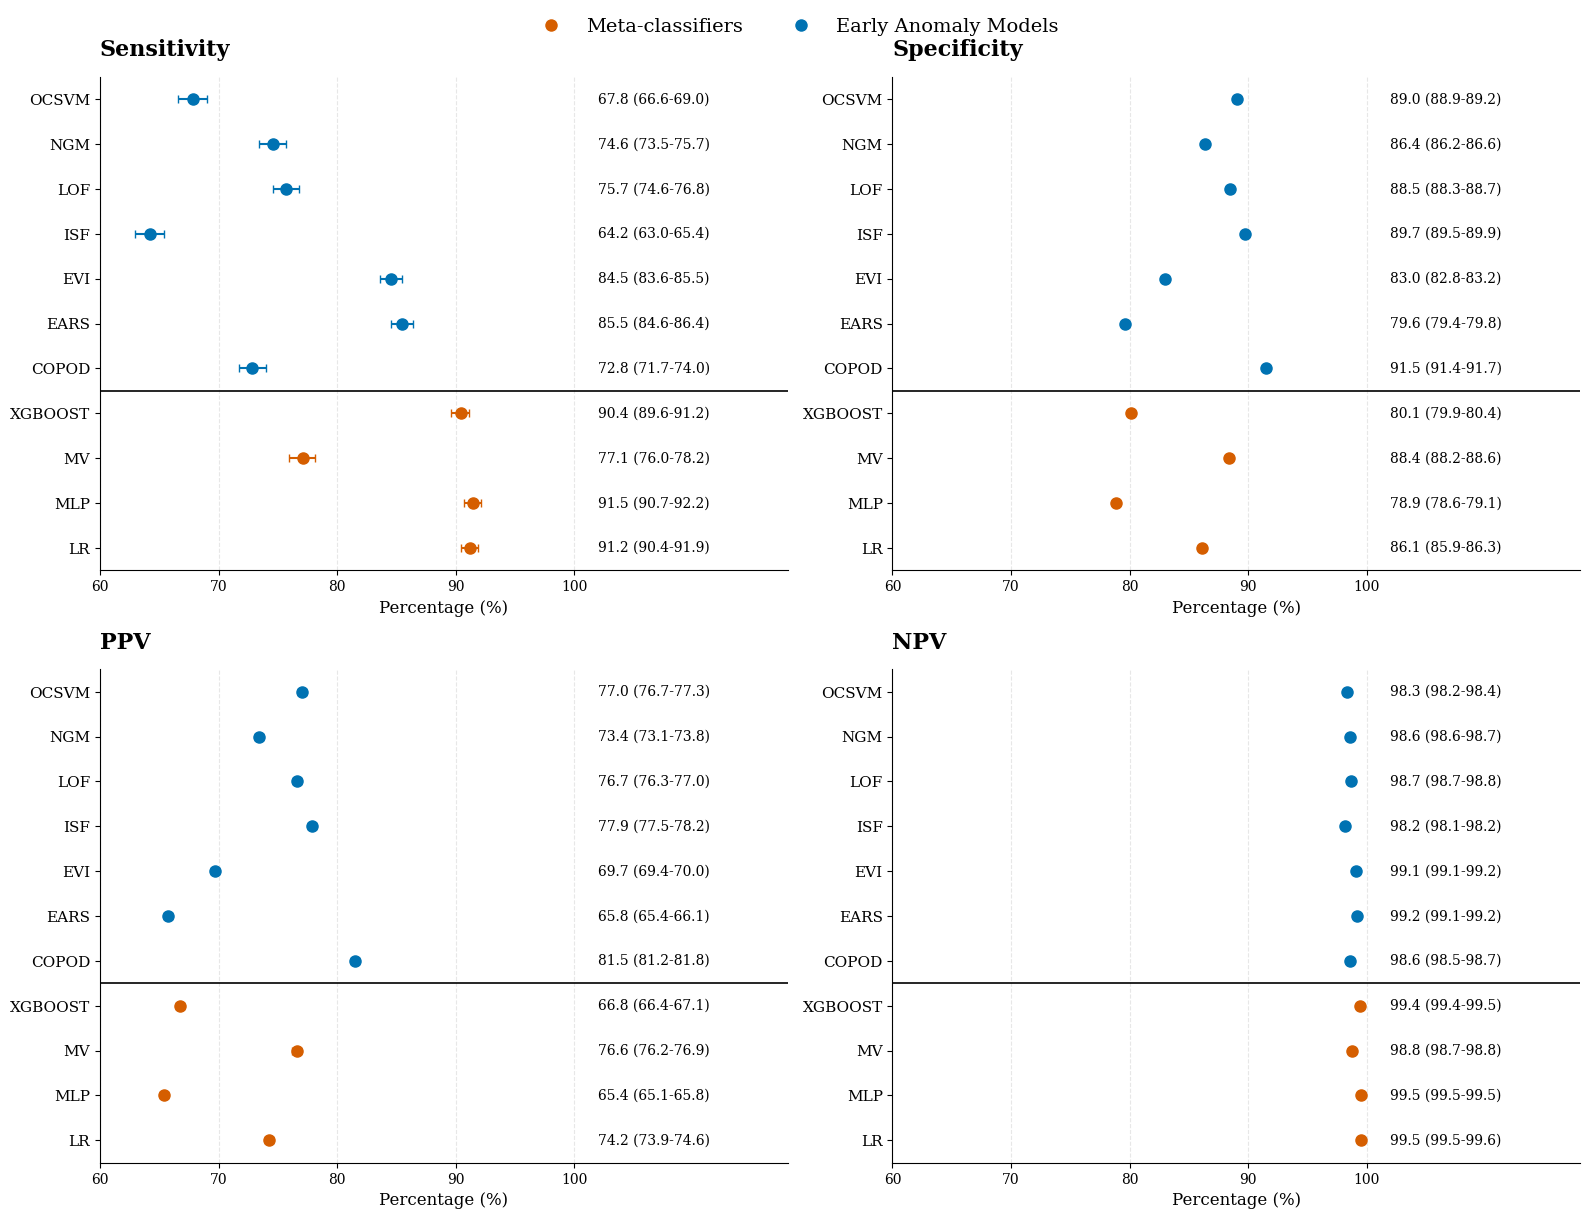

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from matplotlib.lines import Line2D


#df[['Estimate', 'CI_Low', 'CI_High']] = df[['Estimate', 'CI_Low', 'CI_High']].apply(pd.to_numeric)

# Define groupings
classifiers = ['XGBOOST', 'MLP', 'LR', 'MV']
res['Group'] = res['model'].apply(lambda x: 'Meta-classifiers' if x in classifiers else 'EADMs')

# 3. Setup Lancet Aesthetics
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
colors = {'EADMs': '#0072B2', 'Meta-classifiers': '#D55E00'} 

metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 4. Plotting Loop
for i, metric in enumerate(metrics):
    ax = axes[i]
    subset = res[res['Metric'] == metric].copy()
    
    # Sort models: Classifiers on top, Early Anomaly below
    subset['Group_Cat'] = pd.Categorical(subset['Group'], categories=['Meta-classifiers', 'EADMs'])
    subset = subset.sort_values(['Group_Cat', 'model'], ascending=[True, True])
    
    y_pos = range(len(subset))
    
    for j, row in enumerate(subset.itertuples()):
        color = colors[row.Group]
        
        # Plot Dot and Error Bars
        ax.errorbar(row.Estimate, j, 
                    xerr=[[row.Estimate - row.CI_Low], [row.CI_High - row.Estimate]], 
                    fmt='o', color=color, capsize=3, markersize=8, elinewidth=1.5)
        
        # Text label: Estimate (Low-High)
        ax.text(102, j, f"{row.Estimate:.1f} ({row.CI_Low:.1f}-{row.CI_High:.1f})", 
                va='center', fontsize=10)

    # Subplot Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(subset['model'], fontsize=11)
    ax.set_title(metric, fontsize=16, fontweight='bold', loc='left', pad=15)
    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_xlim(60, 118) # Space for labels
    ax.set_xticks([60, 70, 80, 90, 100])
    
    # Clean spines and grid
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    
    # Separation line between groups
    n_class = len(subset[subset['Group'] == 'Meta-classifiers'])
    ax.axhline(y=n_class - 0.5, color='black', linewidth=1.2, linestyle='-')

# 5. Global Legend & Layout
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Meta-classifiers', markerfacecolor=colors['Meta-classifiers'], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Early Anomaly Models', markerfacecolor=colors['EADMs'], markersize=10)
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

In [18]:
res.to_parquet('df_plot_metrics_real.parquet')

In [19]:
dta1 = res[(res.Metric == 'Sensitivity') & (res.Group == 'EADMs')]

des_fun.mean_confidence_interval2(dta1.Estimate)

(75.03, 67.7201, 82.3399)

In [20]:
dta2 = res[(res.Metric == 'Sensitivity') & (res.model.isin(['XGBOOST','MLP','LR'])) ]

des_fun.mean_confidence_interval2(dta2.Estimate)

(91.03, 89.6692, 92.3908)

In [21]:
dta3 = res[(res.Metric == 'Specificity') & (res.Group == 'EADMs')]

des_fun.mean_confidence_interval2(dta3.Estimate)

(86.83, 82.9605, 90.6995)

In [22]:
dta4 = res[(res.Metric == 'Specificity') & (res.model.isin(['XGBOOST','MLP','LR'])) ]

des_fun.mean_confidence_interval2(dta4.Estimate)

(81.7067, 72.0608, 91.3526)

In [23]:
dta5 = res[(res.Metric == 'PPV') & (res.Group == 'EADMs')]

des_fun.mean_confidence_interval2(dta5.Estimate)

(74.5671, 69.6182, 79.5161)

In [24]:
dta6 = res[(res.Metric == 'PPV') & (res.model.isin(['XGBOOST','MLP','LR'])) ]

des_fun.mean_confidence_interval2(dta6.Estimate)

(68.8133, 57.0047, 80.622)

In [25]:
dta7 = res[(res.Metric == 'NPV') & (res.Group == 'EADMs')]

des_fun.mean_confidence_interval2(dta7.Estimate)

(98.6743, 98.328, 99.0206)

In [26]:
dta8 = res[(res.Metric == 'NPV') & (res.model.isin(['XGBOOST','MLP','LR'])) ]

des_fun.mean_confidence_interval2(dta8.Estimate)

(99.4833, 99.3829, 99.5837)

In [27]:
res[res.model == 'MV']

,Metric,Estimate,CI_Low,CI_High,n,model,Group
0,Sensitivity,77.09,75.98,78.15,5765,MV,Meta-classifiers
1,Specificity,88.38,88.20,88.56,122179,MV,Meta-classifiers
2,PPV,76.58,76.24,76.92,60609,MV,Meta-classifiers
3,NPV,98.79,98.72,98.85,109306,MV,Meta-classifiers
